In [1]:
import pandas as pd
import glob

# --- Carregar TODOS os arquivos CSV da pasta ---
files = glob.glob("*.csv")

dfs = []

for f in files:
    base = f.split(".")[0]        # exemplo: "GPT-1shot" ou "llama-2shot"

    # separa pelo primeiro "-" encontrado
    modelo, prompt_type = base.split("-")

    df = pd.read_csv(f)
    df["modelo"] = modelo
    df["prompt_type"] = prompt_type

    dfs.append(df)

# Consolidar tudo em um dataframe único
full = pd.concat(dfs, ignore_index=True)

# Métricas
metricas = ["em", "ex", "cs", "ts", "qas"]

# TABELA MÉTRICAS × MODELO
tabela_metricas = (
    full.groupby(["modelo", "prompt_type", "categoria", "complexidade"])[metricas]
    .mean()
    .reset_index()
)



In [2]:
import pandas as pd

# todas as métricas relevantes
metricas = ["em", "ex", "cs", "ts", "qas", "qtd_retries"]

# garantir que métricas não tenham NaN
full[metricas] = full[metricas].fillna(0)

# gerar tabela MODELO vs métricas
tabela_q1 = (
    full.groupby("modelo")
        .agg({
            "em": "mean",
            "ex": "mean",
            "cs": "mean",
            "ts": "mean",
            "qas": "mean",
            "qtd_retries": "sum"
        })
        .reset_index()
)

tabela_q1

,modelo,em,ex,cs,ts,qas,qtd_retries
0,GPT,0.017544,0.057018,0.851603,0.286767,0.551608,78
1,Gemini,0.008772,0.070175,0.852540,0.316621,0.563513,68
2,llama,0.013158,0.052632,0.815402,0.169262,0.391361,204


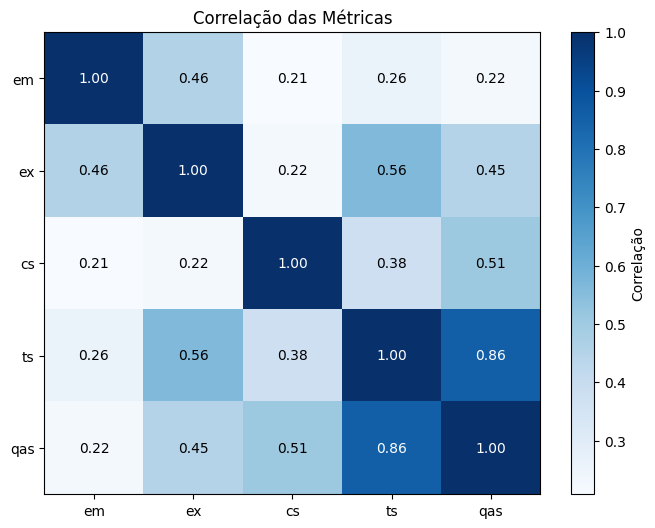

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

metricas = ["em", "ex", "cs", "ts", "qas"]

# garantir que não haja NaN
df = full[metricas].fillna(0)

# correlação
corr = df.corr()

plt.figure(figsize=(8, 6))

# heatmap com tons de azul (Blues)
plt.imshow(corr, cmap="Blues", aspect="auto")

plt.colorbar(label="Correlação")
plt.xticks(range(len(metricas)), metricas)
plt.yticks(range(len(metricas)), metricas)

# valores no centro de cada célula
for i in range(len(metricas)):
    for j in range(len(metricas)):
        valor = corr.iloc[i, j]
        plt.text(
            j, i, f"{valor:.2f}",
            ha="center", va="center",
            color="black" if valor < 0.6 else "white",
            fontsize=10
        )

plt.title("Correlação das Métricas")
plt.grid(False)
plt.show()



In [4]:
metricas = ["em", "ex", "cs", "ts", "qas"]

# listar os prompt_types existentes nos dados
prompt_types = full["prompt_type"].unique()

tabelas_por_prompt = {}

for pt in prompt_types:
    df_pt = full[full["prompt_type"] == pt]

    tabela = (
        df_pt.groupby("modelo")
        .agg({
            "em": "mean",
            "ex": "mean",
            "cs": "mean",
            "ts": "mean",
            "qas": "mean",
            "qtd_retries": "sum"
        })
        .reset_index()
    )

    tabelas_por_prompt[pt] = tabela

In [5]:
tabelas_por_prompt["1shot"]

,modelo,em,ex,cs,ts,qas,qtd_retries
0,GPT,0.000000,0.039474,0.854333,0.316186,0.575424,25
1,Gemini,0.000000,0.052632,0.857183,0.309114,0.564057,19
2,llama,0.013158,0.065789,0.831509,0.181851,0.381518,69


In [6]:
tabelas_por_prompt["2shot"]

,modelo,em,ex,cs,ts,qas,qtd_retries
0,GPT,0.039474,0.078947,0.866236,0.294038,0.553263,26
1,Gemini,0.013158,0.078947,0.866242,0.357825,0.596741,14
2,llama,0.026316,0.065789,0.825637,0.194620,0.420229,66


In [7]:
tabelas_por_prompt["nolinking"]

,modelo,em,ex,cs,ts,qas,qtd_retries
0,GPT,0.013158,0.052632,0.834241,0.250076,0.526137,27
1,Gemini,0.013158,0.078947,0.834196,0.282922,0.529741,35
2,llama,0.000000,0.026316,0.789061,0.131314,0.372336,69


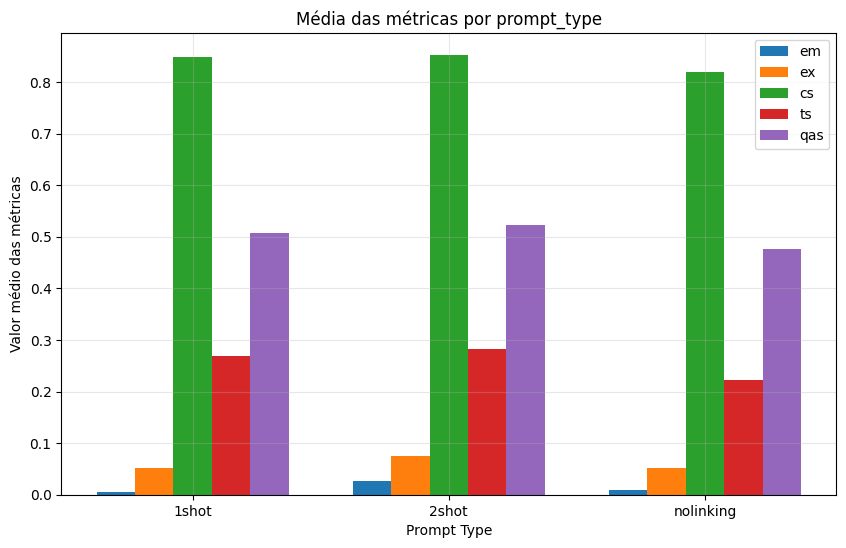

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

metricas = ["em", "ex", "cs", "ts", "qas", "qtd_retries"]
full[metricas] = full[metricas].fillna(0)

# --- MÉDIA POR PROMPT TYPE ---
metricas_simples = ["em", "ex", "cs", "ts", "qas"]

tabela_q2 = (
    full.groupby("prompt_type")[metricas_simples]
        .mean()
        .reset_index()
)

plt.figure(figsize=(10,6))

x = np.arange(len(tabela_q2["prompt_type"]))
width = 0.15

for i, metrica in enumerate(metricas_simples):
    plt.bar(
        x + i*width,
        tabela_q2[metrica],
        width=width,
        label=metrica
    )

plt.xticks(x + width*2, tabela_q2["prompt_type"])
plt.title("Média das métricas por prompt_type")
plt.xlabel("Prompt Type")
plt.ylabel("Valor médio das métricas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


/tmp/ipython-input-2208220600.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


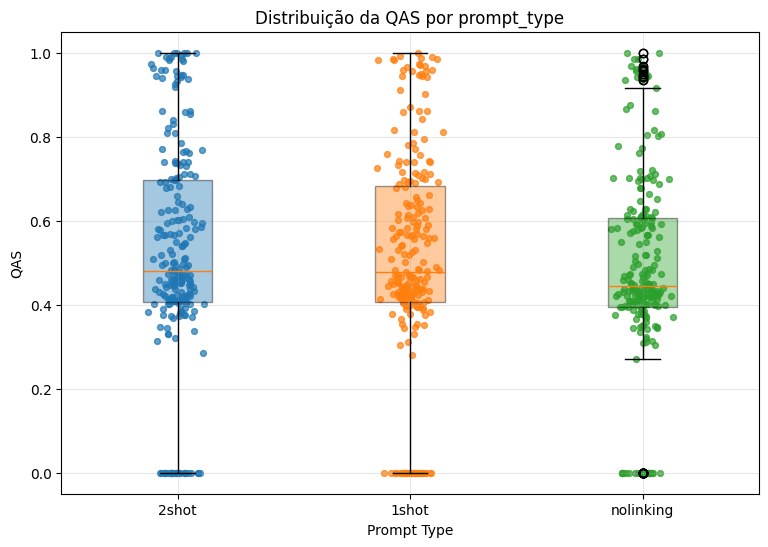

In [9]:
prompt_types = full["prompt_type"].unique()
box_data = [full[full["prompt_type"] == pt]["qas"] for pt in prompt_types]

plt.figure(figsize=(9,6))

bp = plt.boxplot(
    box_data,
    labels=prompt_types,
    patch_artist=True
)

# cores automáticas
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(prompt_types))]

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)

# jitter
for i, pt in enumerate(prompt_types):
    y = full[full["prompt_type"] == pt]["qas"]
    x = np.random.normal(i+1, 0.05, size=len(y))
    plt.scatter(x, y, s=18, color=colors[i], alpha=0.7)

plt.title("Distribuição da QAS por prompt_type")
plt.xlabel("Prompt Type")
plt.ylabel("QAS")
plt.grid(True, alpha=0.3)
plt.show()


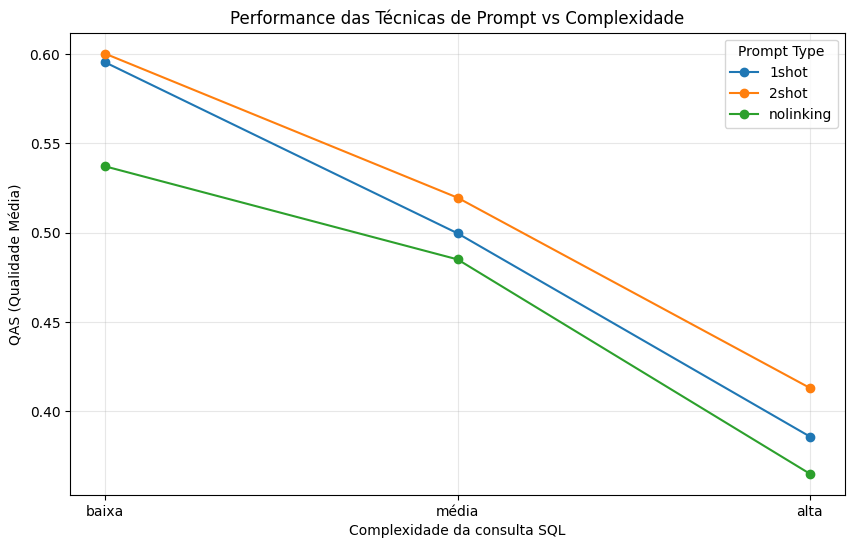

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- Garantir que QAS não tenha NaN ---
full["qas"] = full["qas"].fillna(0)

# Ordenar as complexidades na ordem lógica
ordem_complexidade = ["baixa", "média", "alta"]

# Filtrar apenas complexidades válidas (caso tenha variação nos nomes)
full["complexidade"] = full["complexidade"].str.lower()
full = full[full["complexidade"].isin(ordem_complexidade)]

# Calcular média por prompt_type × complexidade
tabela_complexidade = (
    full.groupby(["prompt_type", "complexidade"])["qas"]
        .mean()
        .reset_index()
)

# Preparar estrutura para plot
prompt_types = tabela_complexidade["prompt_type"].unique()
complexidades_idx = np.arange(len(ordem_complexidade))

plt.figure(figsize=(10, 6))

for prompt in prompt_types:
    valores = []

    for c in ordem_complexidade:
        val = tabela_complexidade[
            (tabela_complexidade["prompt_type"] == prompt) &
            (tabela_complexidade["complexidade"] == c)
        ]["qas"].values

        if len(val) == 0:
            valores.append(0)
        else:
            valores.append(val[0])

    plt.plot(
        complexidades_idx,
        valores,
        marker="o",
        label=prompt
    )

plt.xticks(complexidades_idx, ordem_complexidade)
plt.xlabel("Complexidade da consulta SQL")
plt.ylabel("QAS (Qualidade Média)")
plt.title("Performance das Técnicas de Prompt vs Complexidade")
plt.grid(True, alpha=0.3)
plt.legend(title="Prompt Type")

plt.show()


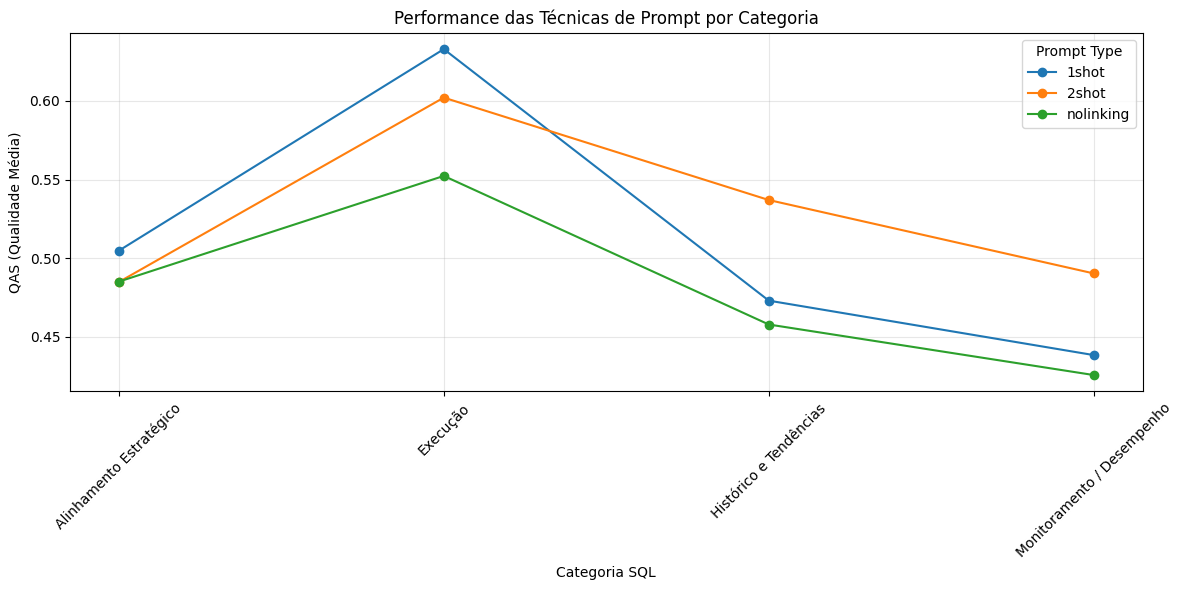

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# --- Garantir que QAS não tenha NaN ---
full["qas"] = full["qas"].fillna(0)

# --- Obter categorias existentes ---
categorias = sorted(full["categoria"].dropna().unique())

# --- Calcular média por prompt_type × categoria ---
tabela_categoria = (
    full.groupby(["prompt_type", "categoria"])["qas"]
        .mean()
        .reset_index()
)

# --- Preparar estrutura ---
prompt_types = tabela_categoria["prompt_type"].unique()
categorias_idx = np.arange(len(categorias))

plt.figure(figsize=(12, 6))

for prompt in prompt_types:
    valores = []

    for cat in categorias:
        val = tabela_categoria[
            (tabela_categoria["prompt_type"] == prompt) &
            (tabela_categoria["categoria"] == cat)
        ]["qas"].values

        valores.append(val[0] if len(val) > 0 else 0)

    plt.plot(
        categorias_idx,
        valores,
        marker="o",
        label=prompt
    )

plt.xticks(categorias_idx, categorias, rotation=45)
plt.xlabel("Categoria SQL")
plt.ylabel("QAS (Qualidade Média)")
plt.title("Performance das Técnicas de Prompt por Categoria")
plt.grid(True, alpha=0.3)
plt.legend(title="Prompt Type")

plt.tight_layout()
plt.show()


/tmp/ipython-input-1668514081.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


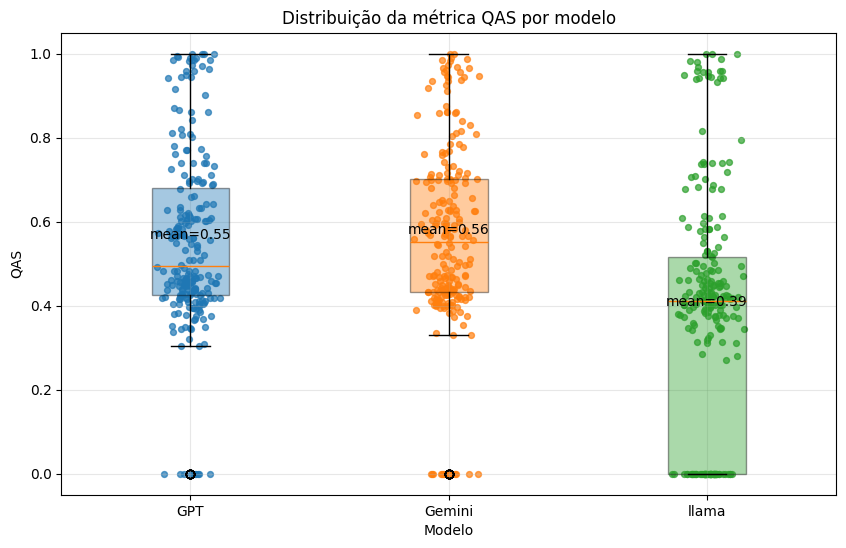

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --- garantir que qas não tenha NaN ---
full["qas"] = full["qas"].fillna(0)

modelos = full["modelo"].unique()
box_data = [full[full["modelo"] == m]["qas"] for m in modelos]

plt.figure(figsize=(10, 6))

# Gerar cores automaticamente a partir de colormap
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(modelos))]

# --- BOX PLOT ---
bp = plt.boxplot(
    box_data,
    labels=modelos,
    patch_artist=True
)

# Aplicar cores automaticamente no boxplot
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)

# --- SCATTER JITTER ---
for i, modelo in enumerate(modelos):
    y = full[full["modelo"] == modelo]["qas"]

    # jitter na horizontal
    x = np.random.normal(loc=i+1, scale=0.05, size=len(y))

    plt.scatter(
        x,
        y,
        alpha=0.7,
        s=18,
        color=colors[i]
    )

# --- Estatísticas extras (média) ---
for i, data in enumerate(box_data):
    mean_val = np.mean(data)
    plt.text(
        i + 1,
        mean_val,
        f"mean={mean_val:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black"
    )

plt.title("Distribuição da métrica QAS por modelo")
plt.xlabel("Modelo")
plt.ylabel("QAS")
plt.grid(True, alpha=0.3)

plt.show()



In [13]:
import numpy as np

def bootstrap_ci(data, n_bootstrap=10000, alpha=0.05):
    boot_means = []
    data = np.array(data)

    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(sample.mean())

    lower = np.percentile(boot_means, 100 * (alpha / 2))
    upper = np.percentile(boot_means, 100 * (1 - alpha / 2))

    return np.mean(data), lower, upper


In [14]:
ci_resultados = []

for modelo in full["modelo"].unique():
    qas_vals = full[full["modelo"] == modelo]["qas"].values
    mean, low, high = bootstrap_ci(qas_vals)

    ci_resultados.append({
        "modelo": modelo,
        "qas_mean": mean,
        "ci_95_low": low,
        "ci_95_high": high
    })

ci_df = pd.DataFrame(ci_resultados)
ci_df


,modelo,qas_mean,ci_95_low,ci_95_high
0,GPT,0.551608,0.524114,0.580067
1,Gemini,0.563513,0.533585,0.591516
2,llama,0.391361,0.354312,0.428696


In [15]:
from scipy.stats import wilcoxon
import itertools

modelos = full["modelo"].unique()
comparacoes = []

for m1, m2 in itertools.combinations(modelos, 2):
    df1 = full[full["modelo"] == m1].sort_index()["qas"].values
    df2 = full[full["modelo"] == m2].sort_index()["qas"].values

    stat, p = wilcoxon(df1, df2)

    comparacoes.append({
        "modelo_1": m1,
        "modelo_2": m2,
        "p_value": p,
        "significativo (α=0.05)": p < 0.05
    })

pd.DataFrame(comparacoes)


,modelo_1,modelo_2,p_value,significativo (α=0.05)
0,GPT,Gemini,4.297626e-01,False
1,GPT,llama,1.725220e-18,True
2,Gemini,llama,3.784119e-15,True


In [16]:
from scipy.stats import wilcoxon

prompt_types = full["prompt_type"].unique()
resultados_prompt = []

for pt in prompt_types:
    subset = full[full["prompt_type"] == pt]

    for m1, m2 in itertools.combinations(modelos, 2):
        v1 = subset[subset["modelo"] == m1]["qas"].values
        v2 = subset[subset["modelo"] == m2]["qas"].values

        if len(v1) == len(v2) and len(v1) > 0:
            _, p = wilcoxon(v1, v2)

            resultados_prompt.append({
                "prompt_type": pt,
                "modelo_1": m1,
                "modelo_2": m2,
                "p_value": p,
                "significativo": p < 0.05
            })

pd.DataFrame(resultados_prompt)


,prompt_type,modelo_1,modelo_2,p_value,significativo
0,2shot,GPT,Gemini,4.052239e-01,False
1,2shot,GPT,llama,1.653507e-07,True
2,2shot,Gemini,llama,1.406330e-06,True
3,1shot,GPT,Gemini,6.580889e-01,False
4,1shot,GPT,llama,7.701284e-07,True
5,1shot,Gemini,llama,7.143923e-06,True
6,nolinking,GPT,Gemini,5.702646e-01,False
7,nolinking,GPT,llama,2.784677e-07,True
8,nolinking,Gemini,llama,4.931296e-06,True


In [2]:
import pandas as pd
import glob

files = glob.glob("*.csv")
dfs = []

for f in files:
    metodo, modelo = f.replace(".csv", "").split("-", 1)
    df = pd.read_csv(f)
    df["metodo"] = metodo
    df["modelo"] = modelo
    dfs.append(df)

full = pd.concat(dfs, ignore_index=True)

tabela_custos = (
    full.groupby(["modelo", "metodo"])
        .agg(
            custo_medio=("custo", "mean"),
            custo_total=("custo", "sum"),
            tokens_medios=("total_tokens", "mean"),
            tempo_medio_ms=("tempo_ms", "mean")
        )
        .reset_index()
)

tabela_custos


,modelo,metodo,custo_medio,custo_total,tokens_medios,tempo_medio_ms
0,linking-gemini-2.5-flash,no,0.000169,0.012823,1806.236842,5550.065789
1,linking-gpt-4o-mini,no,0.000330,0.025073,1792.973684,5071.447368
2,linking-llama-3.1-8b,no,0.000098,0.007483,1790.276316,5422.986842
3,shot-gemini-2.5-flash,1,0.000224,0.016989,2319.434211,3476.078947
4,shot-gemini-2.5-flash,2,0.000191,0.014485,2106.236842,5789.592105
5,shot-gpt-4o-mini,1,0.000364,0.027627,1996.592105,4956.671053
6,shot-gpt-4o-mini,2,0.000385,0.029245,2112.263158,5234.197368
7,shot-llama-3.1-8b,1,0.000110,0.008382,2005.184211,4879.539474
